# HOG + SVM — Hiragana Character Recognition

Trains a Support Vector Machine on HOG features extracted from hand-drawn Hiragana images.
Each character class has its own folder of 100 JPEG images.

### Pipeline
```
Raw .jpg images → Grayscale → Resize (64×64) → HOG features → StandardScaler → SVC (RBF) → Evaluate
```

### Sections
1. Install & Import
2. Configuration
3. HOG Feature Extraction
4. Load Dataset
5. Train/Test Split
6. GridSearchCV — Tune SVM
7. Evaluate on Test Set
8. Per-Class Analysis
9. Confusion Matrix
10. Save Model (.pkl)
11. Single-Image Prediction

## 1. Install & Import

In [10]:
# %pip install opencv-python scikit-image

In [11]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import cv2
from skimage.feature import hog

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, accuracy_score,
    f1_score, confusion_matrix
)

print('✅ All libraries imported.')

✅ All libraries imported.


## 2. Configuration

In [12]:
DATASET_PATH = "../data/hiragana"   # folder where each sub-folder = one character class
IMG_SIZE     = (64, 64)             # resize target — square, divisible by HOG cell size
TEST_SIZE    = 0.2                  # 80 / 20 split
RANDOM_STATE = 42

print(f'Dataset path : {DATASET_PATH}')
print(f'Image size   : {IMG_SIZE}')
print(f'Test split   : {TEST_SIZE*100:.0f}%')

Dataset path : ../data/hiragana
Image size   : (64, 64)
Test split   : 20%


## 3. HOG Feature Extraction

In [13]:
def extract_hog(img):
    """
    Extract HOG features from a 2-D grayscale image.
    channel_axis=None tells skimage the input has no colour channel.
    """
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        channel_axis=None          # ← required for skimage >= 0.19
    )
    return features

# Quick sanity check
dummy = np.zeros(IMG_SIZE, dtype=np.uint8)
print(f'HOG feature vector length: {len(extract_hog(dummy))}')

HOG feature vector length: 1764


## 4. Load Dataset

In [14]:
data        = []
labels      = []
label_names = []
skipped     = 0

for i, label in enumerate(sorted(os.listdir(DATASET_PATH))):
    folder_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(folder_path):
        continue

    label_names.append(label)

    for file in os.listdir(folder_path):
        if not file.lower().endswith('.jpg'):   # .lower() handles .JPG / .JPEG variants
            continue

        img_path = os.path.join(folder_path, file)
        img      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:                          # guard against unreadable files
            print(f'Warning: could not read {img_path}, skipping.')
            skipped += 1
            continue

        img      = cv2.resize(img, IMG_SIZE)
        features = extract_hog(img)

        data.append(features)
        labels.append(i)

X = np.array(data)
y = np.array(labels)

print(f'Dataset shape   : {X.shape}')
print(f'Number of classes: {len(label_names)}')
print(f'Skipped files   : {skipped}')
print(f'Label names     : {label_names}')

Dataset shape   : (4600, 1764)
Number of classes: 46
Skipped files   : 0
Label names     : ['aa', 'chi', 'ee', 'fu', 'ha', 'he', 'hi', 'ho', 'ii', 'ka', 'ke', 'ki', 'ko', 'ku', 'ma', 'me', 'mi', 'mo', 'mu', 'na', 'ne', 'ni', 'nn', 'no', 'nu', 'oo', 'ra', 're', 'ri', 'ro', 'ru', 'sa', 'se', 'shi', 'so', 'su', 'ta', 'te', 'to', 'tsu', 'uu', 'wa', 'wo', 'ya', 'yo', 'yu']


## 5. Train / Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training samples : {len(y_train)}')
print(f'Test samples     : {len(y_test)}')

Training samples : 3680
Test samples     : 920


## 6. GridSearchCV — Tune SVM

Searches over C, gamma, and kernel using 5-fold cross-validation.

In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC())
])

param_grid = {
    'svm__C':      [1, 10, 50],
    'svm__gamma':  ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1
)

print('⏳ Running GridSearchCV...')
t0 = time.time()
grid.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'\n✅ Done in {elapsed:.1f}s')
print(f'Best parameters : {grid.best_params_}')
print(f'Best CV score   : {grid.best_score_*100:.2f}%')

⏳ Running GridSearchCV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

✅ Done in 44.8s
Best parameters : {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV score   : 98.34%


## 7. Evaluate on Test Set

In [17]:
t0           = time.time()
y_pred       = grid.predict(X_test)
infer_time   = (time.time() - t0) / len(y_test) * 1000   # ms per sample
total_time   = time.time() - t0

# Standard accuracy
acc_standard = accuracy_score(y_test, y_pred)

# Mean per-class accuracy
per_class_accs = []
for cls in range(len(label_names)):
    mask    = (y_test == cls)
    cls_acc = (y_pred[mask] == cls).mean() if mask.any() else 0.0
    per_class_accs.append(cls_acc)
acc_classavg = np.mean(per_class_accs)

macro_f1 = f1_score(y_test, y_pred, average='macro')

print('=' * 50)
print('  HOG + SVM Test Set Results')
print('=' * 50)
print(f'  Standard Accuracy       : {acc_standard*100:.2f}%')
print(f'  Mean Per-Class Accuracy : {acc_classavg*100:.2f}%')
print(f'  Macro F1-Score          : {macro_f1:.4f}')
print(f'  Inference time/sample   : {infer_time:.2f} ms')
print(f'  Total prediction time   : {total_time:.1f}s')
print('=' * 50)
print()
print(classification_report(y_test, y_pred, target_names=label_names))

  HOG + SVM Test Set Results
  Standard Accuracy       : 97.83%
  Mean Per-Class Accuracy : 97.83%
  Macro F1-Score          : 0.9806
  Inference time/sample   : 2.43 ms
  Total prediction time   : 2.2s

              precision    recall  f1-score   support

          aa       1.00      1.00      1.00        20
         chi       1.00      1.00      1.00        20
          ee       0.95      0.90      0.92        20
          fu       1.00      0.95      0.97        20
          ha       1.00      0.95      0.97        20
          he       1.00      1.00      1.00        20
          hi       1.00      1.00      1.00        20
          ho       1.00      1.00      1.00        20
          ii       1.00      1.00      1.00        20
          ka       1.00      0.95      0.97        20
          ke       1.00      0.90      0.95        20
          ki       1.00      0.95      0.97        20
          ko       1.00      1.00      1.00        20
          ku       1.00      0.90      

## 8. Per-Class Analysis

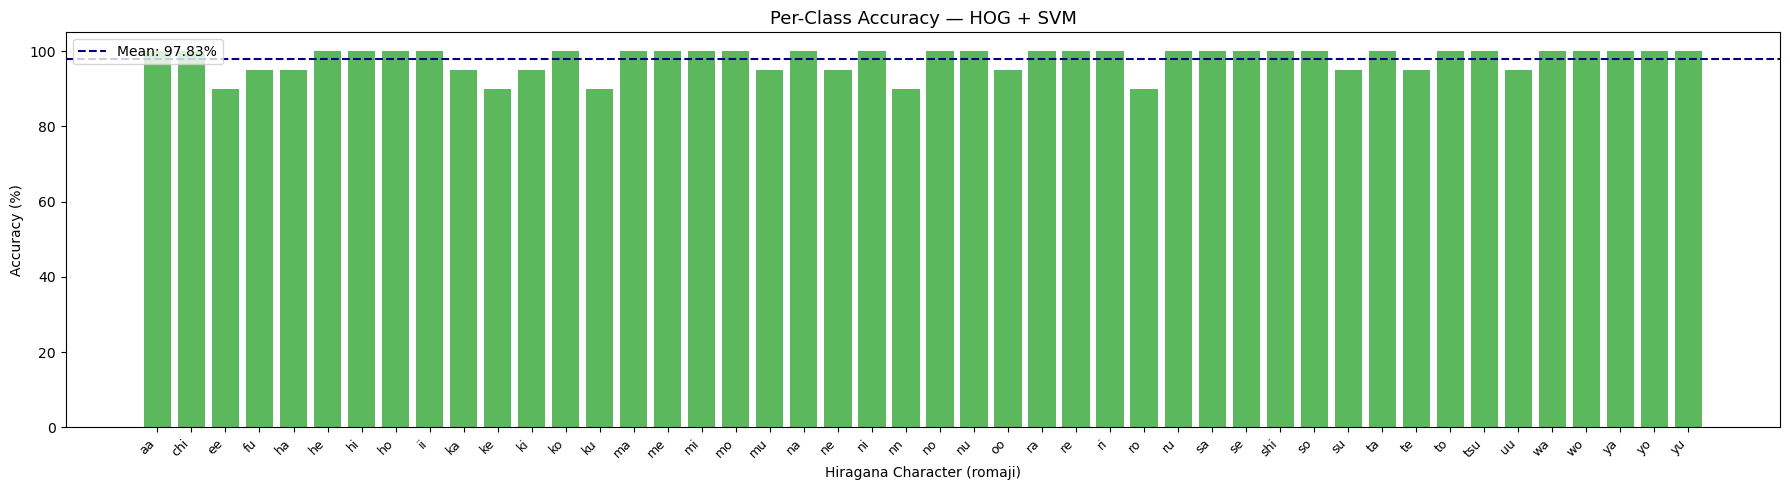

10 Hardest Characters:
     Label    Accuracy
------------------------
        ee      90.00%
        ke      90.00%
        ku      90.00%
        nn      90.00%
        ro      90.00%
        fu      95.00%
        ha      95.00%
        ka      95.00%
        ki      95.00%
        mu      95.00%


In [18]:
# Per-class bar chart
colors = ['#d9534f' if a < 0.75 else '#f0ad4e' if a < 0.85 else '#5cb85c'
          for a in per_class_accs]

plt.figure(figsize=(18, 5))
plt.bar(label_names, [a * 100 for a in per_class_accs], color=colors)
plt.axhline(acc_classavg * 100, color='navy', linestyle='--',
            label=f'Mean: {acc_classavg*100:.2f}%')
plt.title('Per-Class Accuracy — HOG + SVM', fontsize=13)
plt.xlabel('Hiragana Character (romaji)')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

# 10 hardest classes
worst = sorted(enumerate(per_class_accs), key=lambda x: x[1])[:10]
print('10 Hardest Characters:')
print(f'{"Label":>10}  {"Accuracy":>10}')
print('-' * 24)
for idx, acc in worst:
    print(f'{label_names[idx]:>10}  {acc*100:>9.2f}%')

## 9. Confusion Matrix

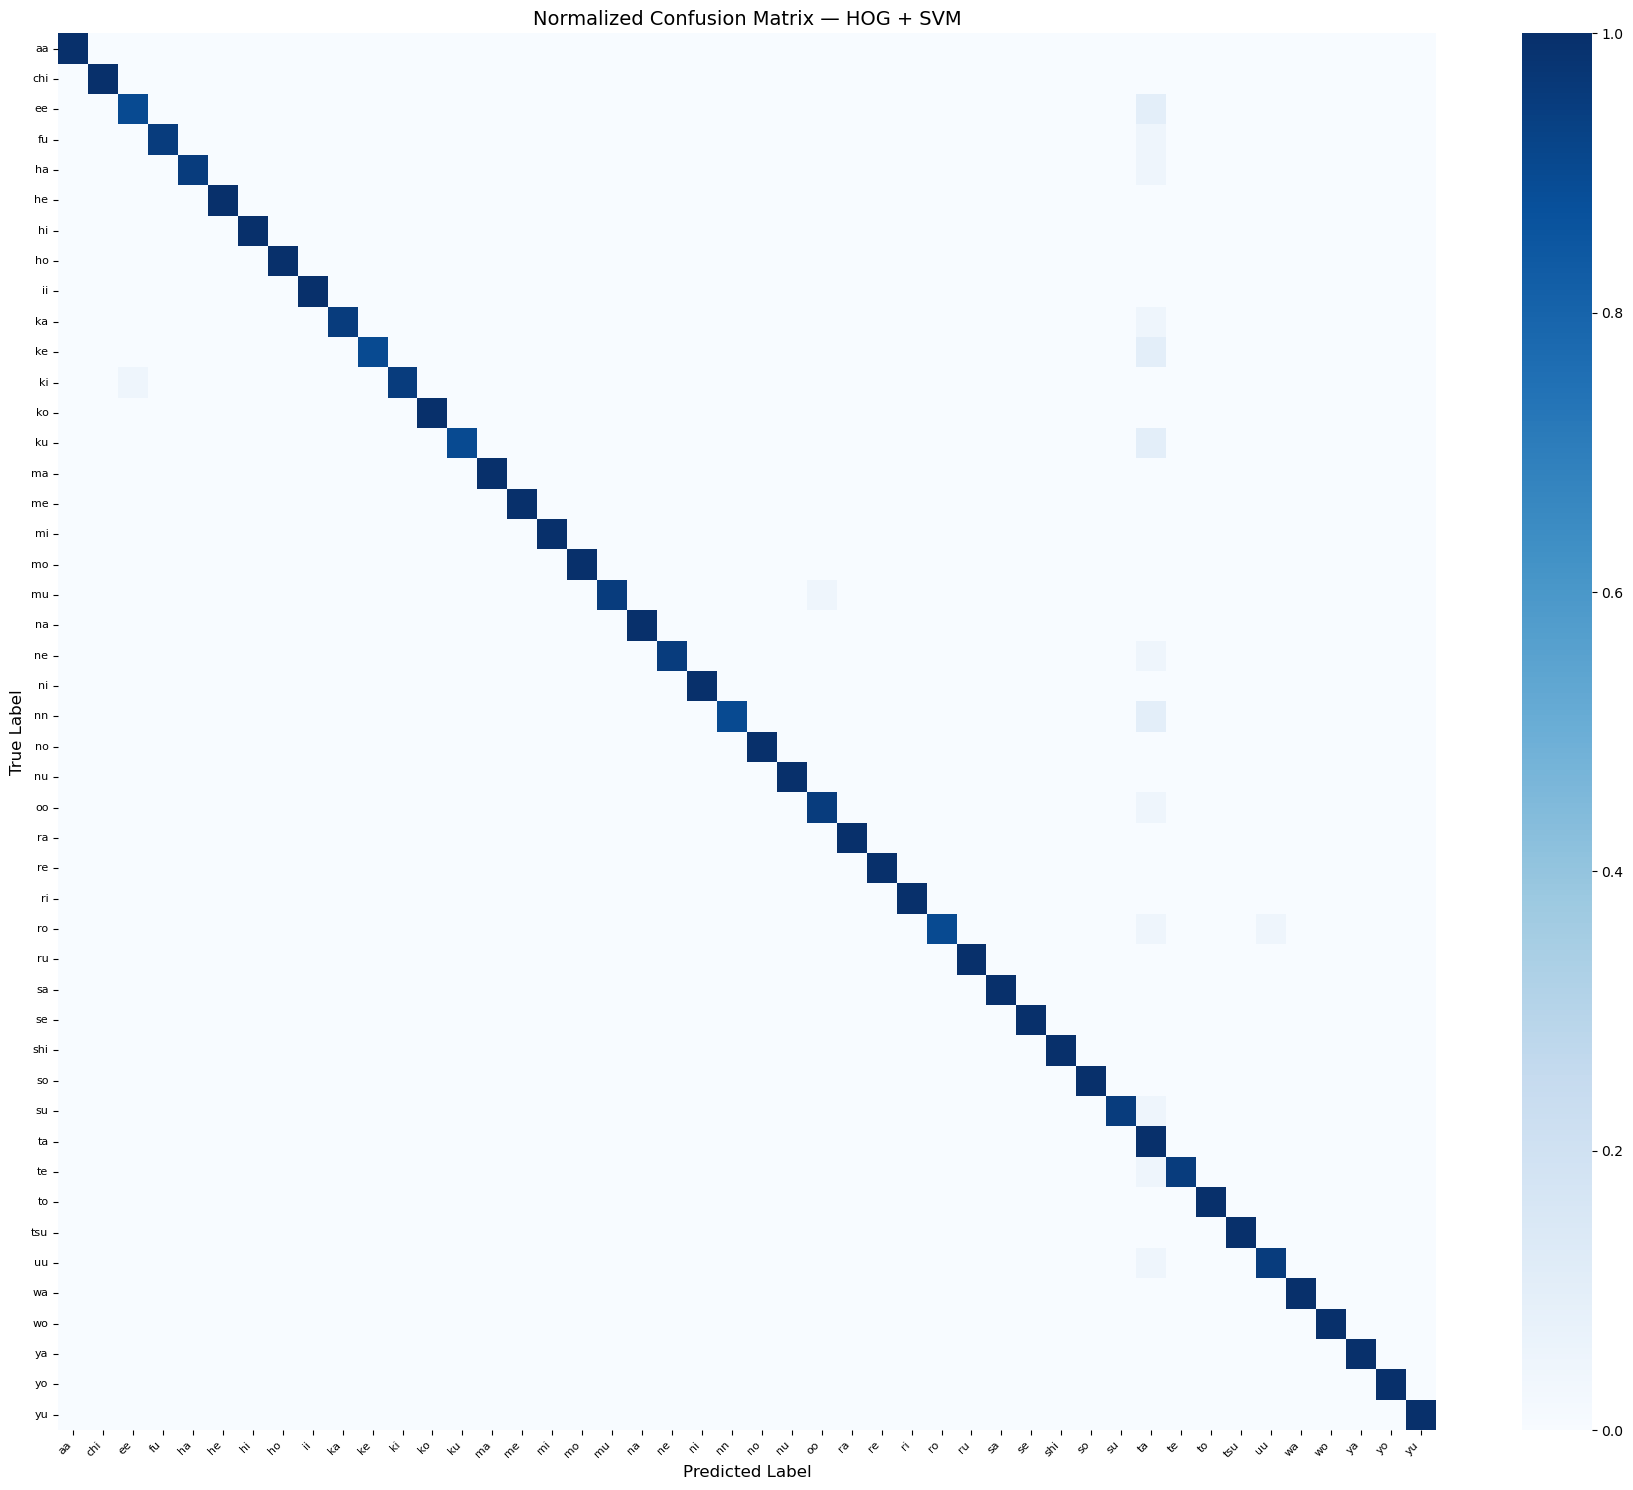

Top 10 Most Confused Pairs (True → Predicted):
      True ->  Predicted  |  Confusion Rate
-----------------------------------------------
        nn ->         ta  |  0.1000 (10.00%)
        ku ->         ta  |  0.1000 (10.00%)
        ke ->         ta  |  0.1000 (10.00%)
        ee ->         ta  |  0.1000 (10.00%)
        uu ->         ta  |  0.0500 (5.00%)
        te ->         ta  |  0.0500 (5.00%)
        su ->         ta  |  0.0500 (5.00%)
        ro ->         uu  |  0.0500 (5.00%)
        ro ->         ta  |  0.0500 (5.00%)
        oo ->         ta  |  0.0500 (5.00%)


In [19]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 15))
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Normalized Confusion Matrix — HOG + SVM', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

# Top-10 most confused pairs
confused_pairs = [
    (cm_norm[i, j], label_names[i], label_names[j])
    for i in range(len(label_names))
    for j in range(len(label_names))
    if i != j
]
confused_pairs.sort(reverse=True)

print('Top 10 Most Confused Pairs (True → Predicted):')
print(f'{"True":>10} -> {"Predicted":>10}  |  Confusion Rate')
print('-' * 47)
for rate, true_c, pred_c in confused_pairs[:10]:
    print(f'{true_c:>10} -> {pred_c:>10}  |  {rate:.4f} ({rate*100:.2f}%)')

## 10. Save Model (.pkl)

In [20]:
os.makedirs('../models', exist_ok=True)

joblib.dump(grid.best_estimator_, '../models/hog_svm.pkl')

print('✅ Model saved:')
print('   ../models/hog_svm.pkl  — best SVM pipeline (scaler + SVC)')
print()
print('Inference pipeline for deployment:')
print('   raw image → grayscale → resize (64×64) → HOG → pipeline.predict')

✅ Model saved:
   ../models/hog_svm.pkl  — best SVM pipeline (scaler + SVC)

Inference pipeline for deployment:
   raw image → grayscale → resize (64×64) → HOG → pipeline.predict


### Quick Reload

In [21]:
# Uncomment to reload on subsequent sessions
model = joblib.load('../models/hog_svm.pkl')
print('Model reloaded.')

Model reloaded.


## 11. Single-Image Prediction

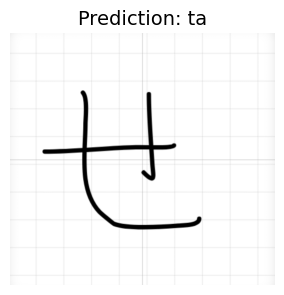

Prediction: ta


'ta'

In [24]:
def predict_image(path, model=None, show=True):
    """
    Predict the Hiragana character in a single image file.

    Parameters
    ----------
    path  : str   — path to the .jpg image
    model : fitted Pipeline (defaults to `grid.best_estimator_`)
    show  : bool  — display the image with the prediction
    """
    if model is None:
        model = grid.best_estimator_

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Guard: cv2.imread returns None when the file is missing / unreadable.
    # Passing None to cv2.resize raises a cryptic OpenCV assertion error.
    if img is None:
        print(f"Error: could not load image at '{path}'.")
        print("Check that the path is correct and the file is a valid image.")
        return None

    img_resized = cv2.resize(img, IMG_SIZE)
    features    = extract_hog(img_resized).reshape(1, -1)
    pred_idx    = model.predict(features)[0]
    pred_label  = label_names[pred_idx]

    if show:
        plt.figure(figsize=(3, 3))
        plt.imshow(img, cmap='gray')
        plt.title(f'Prediction: {pred_label}', fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    print(f'Prediction: {pred_label}')
    return pred_label


# Example — replace with a real path to a Hiragana image
predict_image(r"C:\Users\Gaby\Downloads\Screenshot 2026-03-31 223049.png")

---
## Summary

| Metric | Value |
|---|---|
| Standard Accuracy | see Section 7 |
| Mean Per-Class Accuracy | see Section 7 |
| Macro F1 | see Section 7 |
| Best Params | see Section 6 |
| Saved model | `../models/hog_svm.pkl` |

### Pipeline recap
```
Raw .jpg → grayscale → resize (64×64) → HOG (9 orientations, 8×8 cells, 2×2 blocks)
         → StandardScaler → SVC (RBF, tuned C & gamma) → class label
```